In [11]:
import nltk
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse.linalg import svds


from gensim.summarization.summarizer import summarize as gensim_summarize



text = """
Natural language processing is a field of computer science and artificial intelligence concerned with the interactions between computers and human languages.
In particular, it focuses on programming computers to process and analyze large amounts of natural language data.
The goal is a computer capable of understanding the contents of documents, including the contextual nuances of the language within them.
Technology such as summarization, machine translation, named entity recognition, and sentiment analysis all fall under NLP.
NLP is used in real-world applications such as chatbots, voice assistants, and search engines.
Recent advances in deep learning and transformers have significantly improved the accuracy of NLP systems.
"""

print("=== Gensim summary ===")
try:
    summary_gensim = gensim_summarize(text, ratio=0.4)
    print(summary_gensim)
except ValueError:
    print("Tekst za krótki do podsumowania przez Gensim")

print("\n=== TF-IDF + SVD summary ===")

sentences = nltk.sent_tokenize(text)

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(sentences)

u, s, vt = svds(X, k=1)

sentence_scores = np.abs(u @ np.diag(s)).sum(axis=1)

top_n = 2
top_sentence_indices = sentence_scores.argsort()[-top_n:][::-1]
summary_svd = ' '.join([sentences[i] for i in sorted(top_sentence_indices)])
print(summary_svd)





=== Gensim summary ===
Natural language processing is a field of computer science and artificial intelligence concerned with the interactions between computers and human languages.
In particular, it focuses on programming computers to process and analyze large amounts of natural language data.

=== TF-IDF + SVD summary ===

Natural language processing is a field of computer science and artificial intelligence concerned with the interactions between computers and human languages. In particular, it focuses on programming computers to process and analyze large amounts of natural language data.


In [15]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 293.3/293.3 kB 3.6 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mkowa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


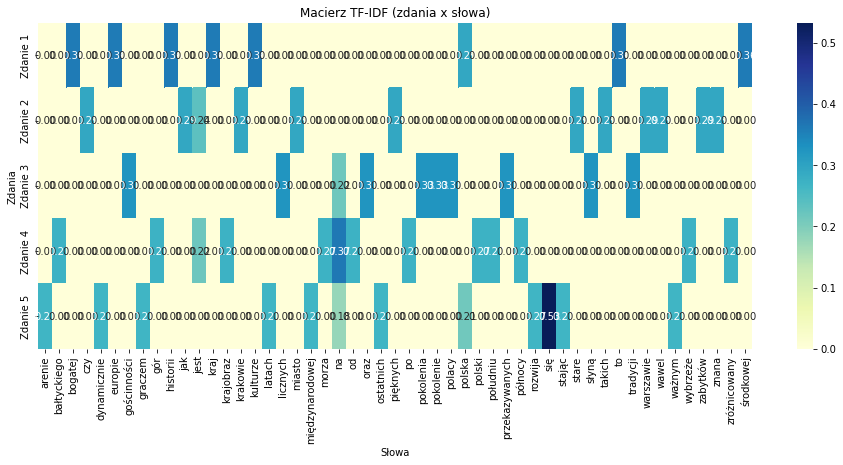

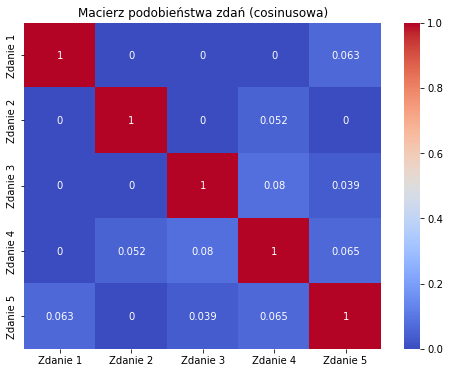

In [3]:
import nltk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt')

text = """
Polska to kraj w Europie Środkowej, o bogatej historii i kulturze. 
Znana jest z pięknych zabytków, takich jak Wawel w Krakowie czy Stare Miasto w Warszawie. 
Polacy słyną z gościnności oraz licznych tradycji przekazywanych z pokolenia na pokolenie. 
Krajobraz Polski jest zróżnicowany – od gór na południu po wybrzeże Morza Bałtyckiego na północy. 
W ostatnich latach Polska rozwija się dynamicznie, stając się ważnym graczem na arenie międzynarodowej.
"""

# Tokenizacja zdań
sentences = nltk.sent_tokenize(text, language='polish')

# TF-IDF
vectorizer = TfidfVectorizer(stop_words=None)
X = vectorizer.fit_transform(sentences)

# Zamiana na gęstą macierz
X_dense = X.todense()

# Słowa (cechy)
feature_names = vectorizer.get_feature_names()

# Wizualizacja macierzy TF-IDF (zdania x słowa)
plt.figure(figsize=(16, 6))
sns.heatmap(X_dense, annot=True, fmt=".2f", cmap="YlGnBu",
            yticklabels=[f"Zdanie {i+1}" for i in range(len(sentences))],
            xticklabels=feature_names)
plt.title("Macierz TF-IDF (zdania x słowa)")
plt.xlabel("Słowa")
plt.ylabel("Zdania")
plt.show()

# Macierz podobieństwa zdań (cosinusowa)
similarity = cosine_similarity(X)

plt.figure(figsize=(8, 6))
sns.heatmap(similarity, annot=True, cmap="coolwarm",
            xticklabels=[f"Zdanie {i+1}" for i in range(len(sentences))],
            yticklabels=[f"Zdanie {i+1}" for i in range(len(sentences))])
plt.title("Macierz podobieństwa zdań (cosinusowa)")
plt.show()
